In [1]:
# https://www.kaggle.com/datasets/smid80/weatherww2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv("00_files/03_weather_ww2_merged.csv", low_memory=False)

In [4]:
df.head()

,STA,Date,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA,PRCP,MAX,MIN,MEA,SNF,NAME,STATE/COUNTRY ID,ELEV,Latitude,Longitude
0,10001,1942-7-1,1.016,25.555556,22.222222,23.888889,0,42,7,1,0.04,78.0,72.0,75.0,0,ACCRA,GH,62,5.6,-0.3
1,10001,1942-7-2,0,28.888889,21.666667,25.555556,0,42,7,2,0,84.0,71.0,78.0,0,ACCRA,GH,62,5.6,-0.3
2,10001,1942-7-3,2.54,26.111111,22.222222,24.444444,0,42,7,3,0.1,79.0,72.0,76.0,0,ACCRA,GH,62,5.6,-0.3
3,10001,1942-7-4,2.54,26.666667,22.222222,24.444444,0,42,7,4,0.1,80.0,72.0,76.0,0,ACCRA,GH,62,5.6,-0.3
4,10001,1942-7-5,0,26.666667,21.666667,24.444444,0,42,7,5,0,80.0,71.0,76.0,0,ACCRA,GH,62,5.6,-0.3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   STA               119040 non-null  int64  
 1   Date              119040 non-null  object 
 2   Precip            119040 non-null  object 
 3   MaxTemp           119040 non-null  float64
 4   MinTemp           119040 non-null  float64
 5   MeanTemp          119040 non-null  float64
 6   Snowfall          117877 non-null  object 
 7   YR                119040 non-null  int64  
 8   MO                119040 non-null  int64  
 9   DA                119040 non-null  int64  
 10  PRCP              117108 non-null  object 
 11  MAX               118566 non-null  float64
 12  MIN               118572 non-null  float64
 13  MEA               118542 non-null  float64
 14  SNF               117877 non-null  object 
 15  NAME              119040 non-null  object 
 16  STATE/COUNTRY ID  11

In [6]:
df.describe()

,STA,MaxTemp,MinTemp,MeanTemp,YR,MO,DA,MAX,MIN,MEA,ELEV,Latitude,Longitude
count,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,118566.000000,118572.000000,118542.000000,119040.000000,119040.000000,119040.000000
mean,29659.435795,27.045111,17.789511,22.411631,43.805284,6.726016,15.797530,81.003745,64.273808,72.644843,416.380385,17.553536,-15.787356
std,20953.209402,8.717817,8.334572,8.297982,1.136718,3.425561,8.794541,14.869361,14.481498,14.211082,1696.652854,19.763832,88.764354
min,10001.000000,-33.333333,-38.333333,-35.555556,40.000000,1.000000,1.000000,-28.000000,-37.000000,-32.000000,1.000000,-27.600000,-175.000000
25%,11801.000000,25.555556,15.000000,20.555556,43.000000,4.000000,8.000000,78.000000,59.000000,69.000000,9.000000,6.750000,-79.500000
50%,22508.000000,29.444444,21.111111,25.555556,44.000000,7.000000,16.000000,85.000000,70.000000,78.000000,26.000000,17.900000,-22.616667
75%,33501.000000,31.666667,23.333333,27.222222,45.000000,10.000000,23.000000,89.000000,74.000000,81.000000,93.000000,27.683333,44.866667
max,82506.000000,50.000000,34.444444,40.000000,45.000000,12.000000,31.000000,122.000000,94.000000,104.000000,9999.000000,67.016667,177.366667


In [7]:
df.isna().sum()

STA                    0
Date                   0
Precip                 0
MaxTemp                0
MinTemp                0
MeanTemp               0
Snowfall            1163
YR                     0
MO                     0
DA                     0
PRCP                1932
MAX                  474
MIN                  468
MEA                  498
SNF                 1163
NAME                   0
STATE/COUNTRY ID       0
ELEV                   0
Latitude               0
Longitude              0
dtype: int64

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   STA               119040 non-null  int64         
 1   Date              119040 non-null  datetime64[ns]
 2   Precip            119040 non-null  object        
 3   MaxTemp           119040 non-null  float64       
 4   MinTemp           119040 non-null  float64       
 5   MeanTemp          119040 non-null  float64       
 6   Snowfall          117877 non-null  object        
 7   YR                119040 non-null  int64         
 8   MO                119040 non-null  int64         
 9   DA                119040 non-null  int64         
 10  PRCP              117108 non-null  object        
 11  MAX               118566 non-null  float64       
 12  MIN               118572 non-null  float64       
 13  MEA               118542 non-null  float64       
 14  SNF 

<Axes: xlabel='MeanTemp', ylabel='Count'>

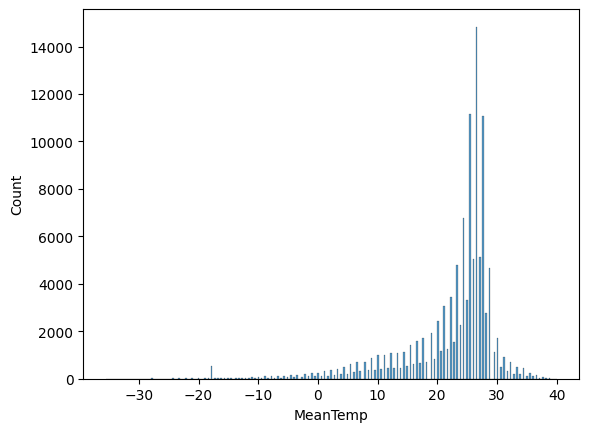

In [10]:
sns.histplot(df["MeanTemp"])

In [11]:
numeric_cols = df.select_dtypes(include=["number"]).columns
df[numeric_cols].corr()["MeanTemp"].sort_values()

Latitude    -0.562551
Longitude   -0.011331
DA          -0.004153
YR           0.010681
ELEV         0.047781
MO           0.050769
STA          0.078112
MIN          0.963279
MinTemp      0.965425
MAX          0.965838
MaxTemp      0.969048
MEA          1.000000
MeanTemp     1.000000
Name: MeanTemp, dtype: float64

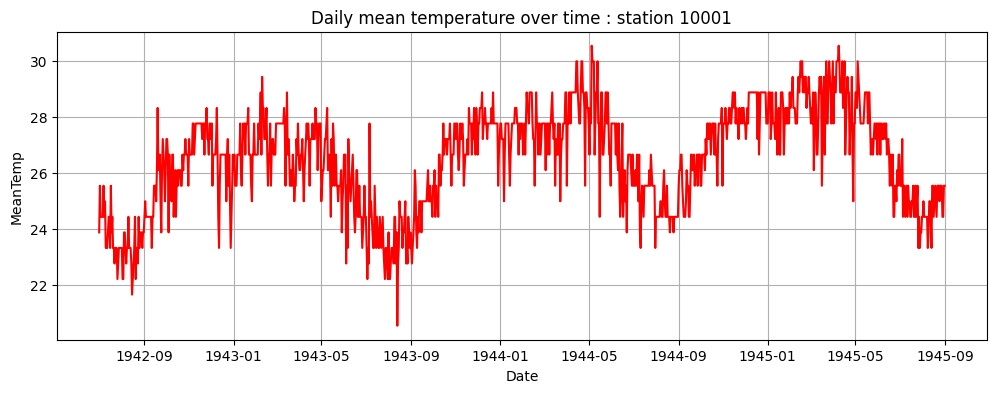

In [12]:
station_id = 10001
df_station = df[df["STA"] == station_id].copy()

df_station = df_station.sort_values("Date")

plt.figure(figsize=(12, 4))
plt.plot(df_station["Date"], df_station["MeanTemp"], color="r")
plt.title(f"Daily mean temperature over time : station {station_id}")
plt.xlabel("Date")
plt.ylabel("MeanTemp")
plt.grid(True)
plt.show()